--- RAW DATA FRAME PREVIEW ---
          tetA_tetracycline  ampC_ampicillin  vanA_vancomycin  \
Sample_1                 77               81               15   
Sample_2                 78               78               17   
Sample_3                 75               80               14   
Sample_4                 71               70               17   
Sample_5                 89               81               12   

          ermB_erythromycin  sul1_sulfonamide  blaCTX_beta_lactam Environment  
Sample_1                 16                14                   3  Wastewater  
Sample_2                 14                 7                   3  Wastewater  
Sample_3                 12                 8                   8  Wastewater  
Sample_4                 13                10                   5  Wastewater  
Sample_5                 16                 4                   6  Wastewater  




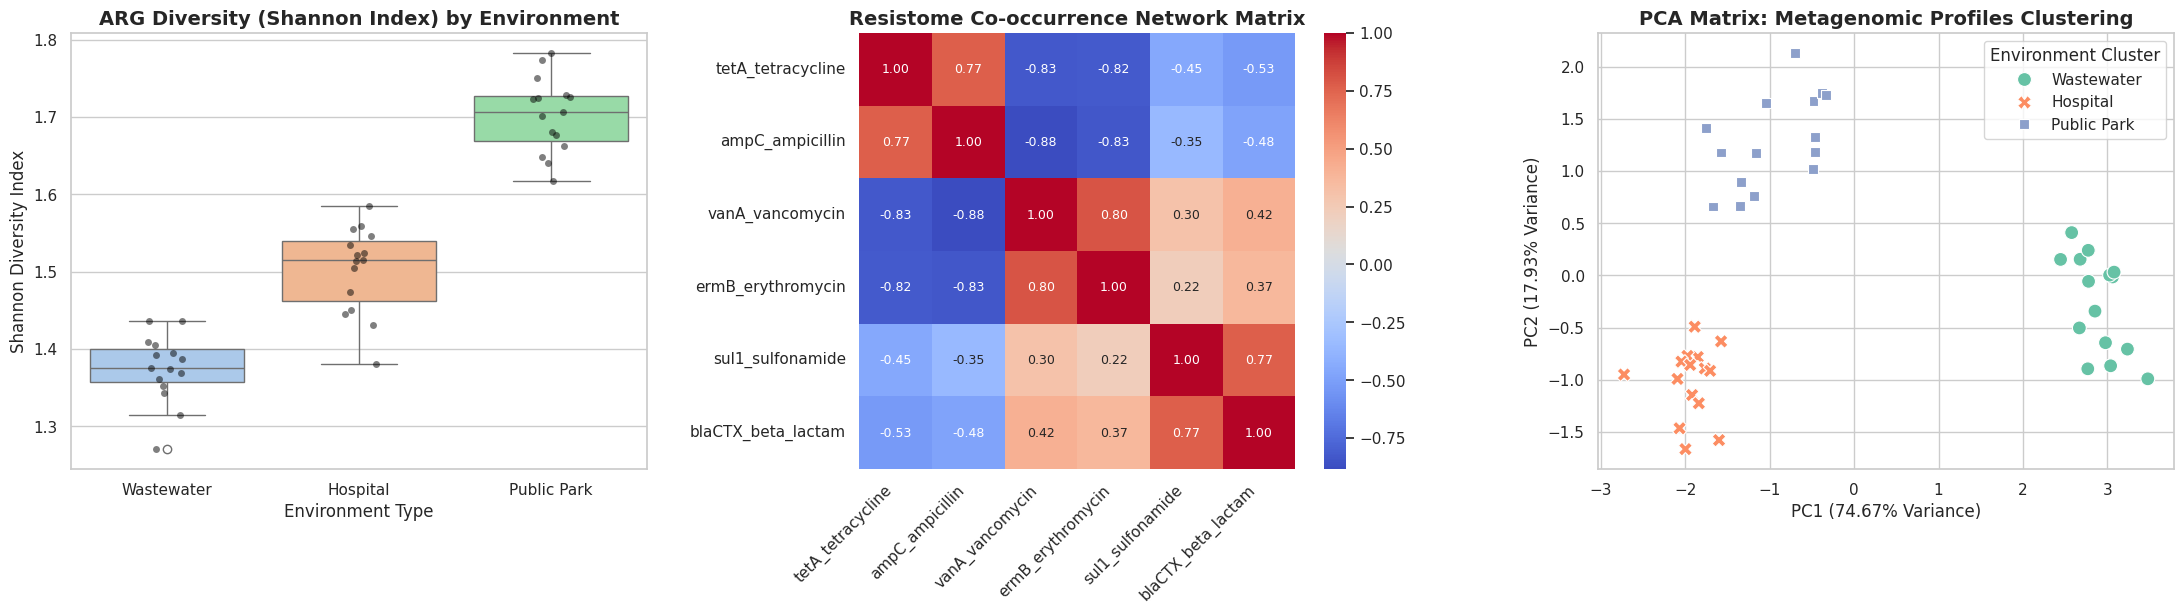

--- EXPLAINED VARIANCE RATIO ---
Principal Component 1 captures: 74.67% of the total genetic variance.
Principal Component 2 captures: 17.93% of the total genetic variance.
Total Explained Variance: 92.59%


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. GENERATE SYNTHETIC METAGENOMIC DATA
# ==========================================
# Simulating raw count data of 6 different Antibiotic Resistance Genes (ARGs)
# across 3 distinct urban environments (Wastewater, Hospital Soil, Public Parks)
np.random.seed(42)
n_samples_per_env = 15

# Environment 1: Wastewater (High Tet/Amp resistance due to runoff)
wastewater = np.random.poisson(lam=[80, 75, 20, 15, 10, 5], size=(n_samples_per_env, 6))
# Environment 2: Hospital Soil (High Van/Erm resistance due to clinical settings)
hospital = np.random.poisson(lam=[10, 15, 90, 85, 20, 30], size=(n_samples_per_env, 6))
# Environment 3: Public Parks (Lower baseline resistance overall)
parks = np.random.poisson(lam=[5, 8, 12, 10, 15, 12], size=(n_samples_per_env, 6))

# Combine into a single matrix
raw_counts = np.vstack([wastewater, hospital, parks])

# Define labels
genes = ['tetA_tetracycline', 'ampC_ampicillin', 'vanA_vancomycin', 'ermB_erythromycin', 'sul1_sulfonamide', 'blaCTX_beta_lactam']
environments = ['Wastewater'] * n_samples_per_env + ['Hospital'] * n_samples_per_env + ['Public Park'] * n_samples_per_env
sample_ids = [f"Sample_{i+1}" for i in range(len(environments))]

# Create the primary DataFrame
df_counts = pd.DataFrame(raw_counts, columns=genes, index=sample_ids)
df_counts['Environment'] = environments

print("--- RAW DATA FRAME PREVIEW ---")
print(df_counts.head())
print("\n" + "="*50 + "\n")


# ==========================================
# 2. DATA PREPROCESSING & NORMALIZATION
# ==========================================
# To account for different sequencing depths, we normalize to Relative Abundance (Compositional Data)
features = df_counts.drop(columns=['Environment'])
row_totals = features.sum(axis=1)
df_relative = features.div(row_totals, axis=0)

# Apply a Log2 transformation to stabilize variance across high/low abundance features
# We add a small pseudo-count (1e-4) to avoid log(0)
df_log = np.log2(df_relative + 1e-4)


# ==========================================
# 3. ADVANCED STATISTICAL ANALYSIS
# ==========================================
# Metric 1: Calculate Shannon Entropy (Alpha Diversity of resistance genes per sample)
def calculate_shannon(row):
    p = row[row > 0]
    return -np.sum(p * np.log(p))

df_counts['Shannon_Diversity'] = df_relative.apply(calculate_shannon, axis=1)

# Metric 2: Generate an ARG Co-occurrence Correlation Matrix
corr_matrix = df_relative.corr(method='spearman')


# ==========================================
# 4. DIMENSIONALITY REDUCTION (PCA)
# ==========================================
# Scale features for optimal PCA performance
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_log)

# Run PCA to reduce data down to 2 Principal Components
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_features)

df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'], index=sample_ids)
df_pca['Environment'] = df_counts['Environment']

# Calculate variance explained
var_explained = pca.explained_variance_ratio_ * 100


# ==========================================
# 5. DATA VISUALIZATION BLOCK
# ==========================================
# Set up a clean, professional aesthetic
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot A: Shannon Diversity across Environments (Boxplot)
sns.boxplot(ax=axes[0], data=df_counts, x='Environment', y='Shannon_Diversity', palette='pastel', hue='Environment', legend=False)
sns.stripplot(ax=axes[0], data=df_counts, x='Environment', y='Shannon_Diversity', color='black', alpha=0.5, size=5)
axes[0].set_title('ARG Diversity (Shannon Index) by Environment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Shannon Diversity Index')
axes[0].set_xlabel('Environment Type')

# Plot B: Co-occurrence Heatmap (Correlation of Resistances)
sns.heatmap(ax=axes[1], data=corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, square=True, annot_kws={"size": 9})
axes[1].set_title('Resistome Co-occurrence Network Matrix', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# Plot C: PCA Space Cluster Map
sns.scatterplot(ax=axes[2], data=df_pca, x='PC1', y='PC2', hue='Environment', style='Environment', s=100, palette='Set2')
axes[2].set_title('PCA Matrix: Metagenomic Profiles Clustering', fontsize=14, fontweight='bold')
axes[2].set_xlabel(f'PC1 ({var_explained[0]:.2f}% Variance)')
axes[2].set_ylabel(f'PC2 ({var_explained[1]:.2f}% Variance)')
axes[2].legend(title='Environment Cluster', loc='best')

plt.tight_layout()
plt.show()

print("--- EXPLAINED VARIANCE RATIO ---")
print(f"Principal Component 1 captures: {var_explained[0]:.2f}% of the total genetic variance.")
print(f"Principal Component 2 captures: {var_explained[1]:.2f}% of the total genetic variance.")
print(f"Total Explained Variance: {sum(var_explained):.2f}%")